In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
np.set_printoptions(suppress=True)
from tqdm import tqdm

# Strategy stats
win_rate = 0.5364
avg_win = 676702.26
avg_loss = -231301.33
starting_capital = 1000000
n_simulations = 10000
n_trades = 112

# Tracking
ending_capitals = []
max_drawdowns = []
max_win_streaks = []
max_loss_streaks = []
max_ending_capital = []
bankruptcies = 0
profitable_runs = 0
drawdown_runs = 0

# Monte Carlo
for sim in tqdm(range(n_simulations), desc="Simulating..."):
    equity = [starting_capital]
    loss_streak = 0
    win_streak = 0
    max_win_streak = 0
    max_loss_streak = 0
    max_ending_capital = 0
    peak = starting_capital
    max_dd = 0

    for _ in range(n_trades):
        current_equity = equity[-1]

        # Dynamic risk logic
        risk_pct = 0.01 if loss_streak >= 4 else 0.02
        risk_amount = current_equity * risk_pct

        if np.random.rand() < win_rate:
            profit = (avg_win / abs(avg_loss)) * risk_amount
            equity.append(current_equity + profit)
            loss_streak = 0
            win_streak += 1
            max_win_streak = max(max_win_streak, win_streak)
        else:
            loss = risk_amount
            equity.append(current_equity - loss)
            win_streak = 0
            loss_streak += 1
            max_loss_streak = max(max_loss_streak, loss_streak)

        # Drawdown tracking
        peak = max(peak, equity[-1])
        dd = (equity[-1] - peak) / peak
        max_dd = min(max_dd, dd)

        if equity[-1] <= 0:
            bankruptcies += 1
            break

    ending_capitals.append(equity[-1])
    max_drawdowns.append(max_dd)
    max_win_streaks.append(max_win_streak)
    max_loss_streaks.append(max_loss_streak)

    if equity[-1] > starting_capital:
        profitable_runs += 1
    if max_dd < -0.3:
        drawdown_runs += 1

# Summary
results_summary = {
    "Max Ending Capital(Max)": max(ending_capitals),
    "Average Ending Capital": f"${np.mean(ending_capitals):,.2f}",
    "Median Ending Capital": f"${np.median(ending_capitals):,.2f}",
    "Worst Ending Capital": f"${np.min(ending_capitals):,.2f}",
    "Simulations in Profit": f"{profitable_runs}/{n_simulations}",
    "Simulations in Drawdown (>30%)": f"{drawdown_runs}/{n_simulations}",
    "Bankruptcies": bankruptcies,
    "Average Max Drawdown": f"{np.mean(max_drawdowns)*100:.2f}%",
    "Worst Max Drawdown": f"{np.min(max_drawdowns)*100:.2f}%",
    "Max Win Streak (Avg)": f"{np.mean(max_win_streaks):.2f}",
    "Max Win Streak (Max)": max(max_win_streaks),
    "Max Loss Streak (Avg)": f"{np.mean(max_loss_streaks):.2f}",
    "Max Loss Streak (Max)": max(max_loss_streaks),
}

print("\n--- MONTE CARLO SIMULATION SUMMARY ---")
for k, v in results_summary.items():
    print(f"{k:35}: {v}")

Simulating...: 100%|██████████| 10000/10000 [00:01<00:00, 5402.79it/s]



--- MONTE CARLO SIMULATION SUMMARY ---
Max Ending Capital(Max)            : 45861414.623765536
Average Ending Capital             : $11,033,819.16
Median Ending Capital              : $10,129,366.69
Worst Ending Capital               : $2,025,308.16
Simulations in Profit              : 10000/10000
Simulations in Drawdown (>30%)     : 0/10000
Bankruptcies                       : 0
Average Max Drawdown               : -10.19%
Worst Max Drawdown                 : -25.61%
Max Win Streak (Avg)               : 6.79
Max Win Streak (Max)               : 19
Max Loss Streak (Avg)              : 5.60
Max Loss Streak (Max)              : 17


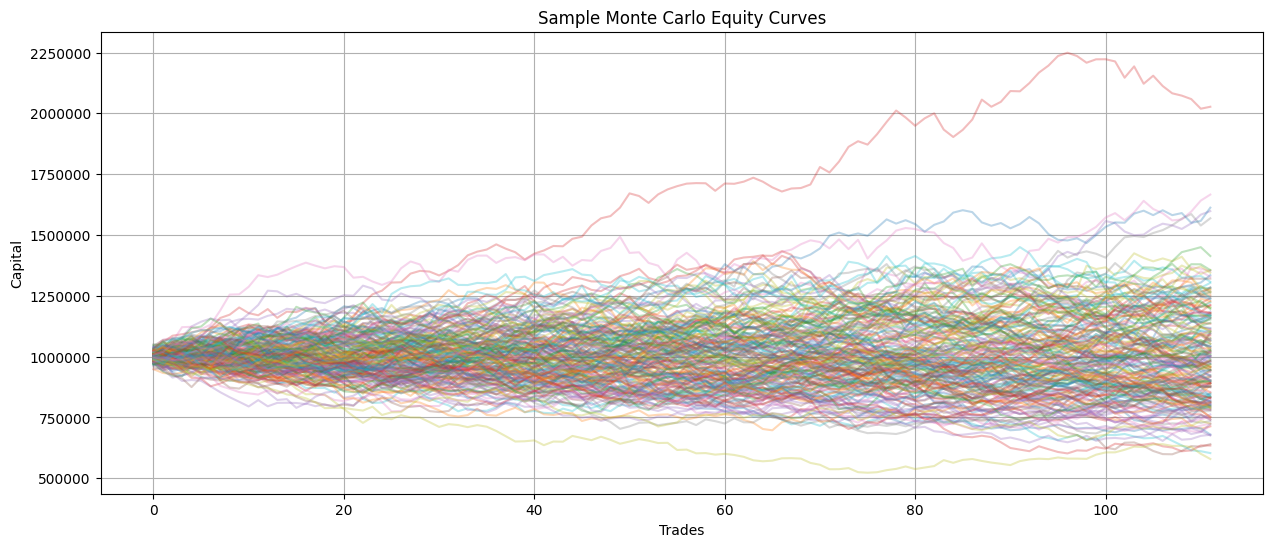

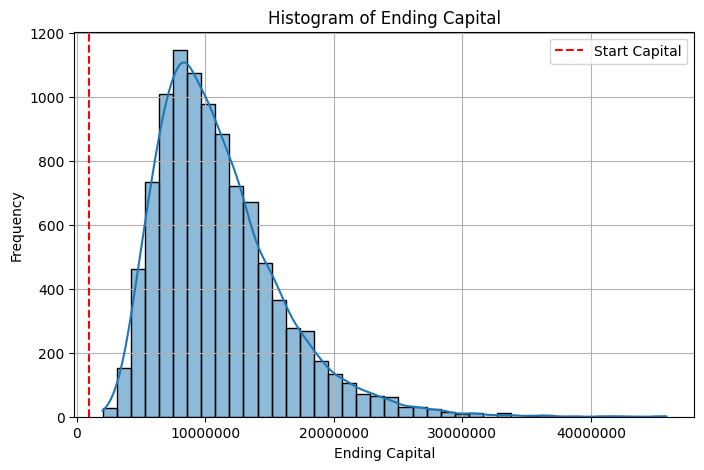

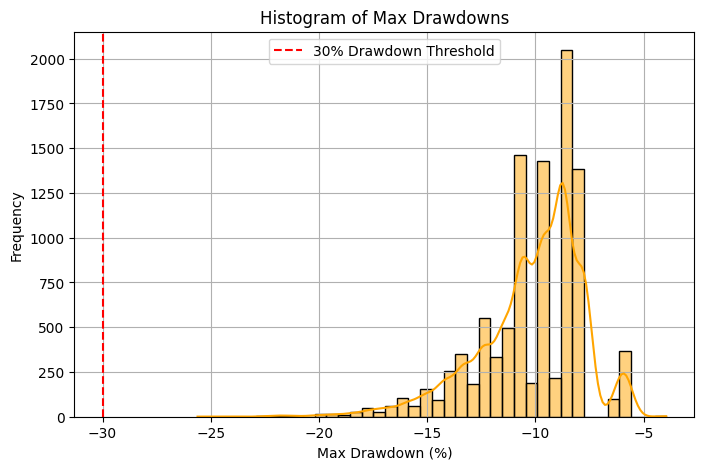

In [3]:
# Plotting
plt.figure(figsize=(15, 6))
for _ in range(200):
    sample = np.random.choice(ending_capitals, n_trades, replace=True)
    equity = np.cumprod(1 + np.random.normal(0, 0.02, n_trades)) * starting_capital
    plt.plot(equity, alpha=0.3)
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y')
plt.title("Sample Monte Carlo Equity Curves")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.grid(True)
plt.show()

# Histogram: Ending Capital
plt.figure(figsize=(8, 5))
sns.histplot(ending_capitals, bins=40, kde=True)
plt.axvline(starting_capital, color='red', linestyle='--', label='Start Capital')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
plt.title("Histogram of Ending Capital")
plt.xlabel("Ending Capital")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Histogram: Max Drawdowns
plt.figure(figsize=(8, 5))
sns.histplot([dd * 100 for dd in max_drawdowns], bins=40, kde=True, color='orange')
plt.axvline(-30, color='red', linestyle='--', label='30% Drawdown Threshold')
plt.title("Histogram of Max Drawdowns")
plt.xlabel("Max Drawdown (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()